In [ ]:
# instalamos y habilitamos nuestro driver

# pip install mysql-connector-python

import mysql.connector 

In [ ]:
# Create connection
clave = 'ingrese su contraseña'

conexion = mysql.connector.connect(user = 'root', password = clave,
                                   host =  'localhost', port = '3306',
                                   database = 'chinook')

In [3]:
print(conexion)

In [4]:
# Cómo ejecutar consultas desde python
# Para hacer consultas requiero de un cursor

cursor = conexion.cursor()

# El esquema para hacer consultas es como sigue

cursor.execute('show tables')

In [6]:
for i in cursor.fetchall():
    print(i)

('album',)
('artist',)
('customer',)
('employee',)
('genre',)
('invoice',)
('invoiceline',)
('mediatype',)
('playlist',)
('playlisttrack',)
('track',)


In [7]:
cursor.execute('select InvoiceID, Total from invoice where CustomerID = 2 ')

for i in cursor.fetchall():
    print(i)

(1, Decimal('1.98'))
(12, Decimal('13.86'))
(67, Decimal('8.91'))
(196, Decimal('1.98'))
(219, Decimal('3.96'))
(241, Decimal('5.94'))
(293, Decimal('0.99'))


In [8]:
cursor.execute('select Country as Pais, count(*) as Frecuencia from customer group by Country')

for i in cursor.fetchall():
    print(i)

('Brazil', 5)
('Germany', 4)
('Canada', 8)
('Norway', 1)
('Czech Republic', 2)
('Austria', 1)
('Belgium', 1)
('Denmark', 1)
('USA', 13)
('Portugal', 2)
('France', 5)
('Finland', 1)
('Hungary', 1)
('Ireland', 1)
('Italy', 1)
('Netherlands', 1)
('Poland', 1)
('Spain', 1)
('Sweden', 1)
('United Kingdom', 3)
('Australia', 1)
('Argentina', 1)
('Chile', 1)
('India', 2)


In [9]:
query = 'select Country as Pais, count(*) as Frecuencia	from customer group by Country limit 10'

cursor.execute(query)

for i in cursor.fetchall():
    print(i)

('Brazil', 5)
('Germany', 4)
('Canada', 8)
('Norway', 1)
('Czech Republic', 2)
('Austria', 1)
('Belgium', 1)
('Denmark', 1)
('USA', 13)
('Portugal', 2)


In [10]:
# Pasar de una cosulta SQL a un DF de pandas

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_sql(query, con= conexion)

C:\Windows\Temp\ipykernel_5896\4020598663.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con= conexion)


In [20]:
df.columns

Index(['Pais', 'Frecuencia'], dtype='object')

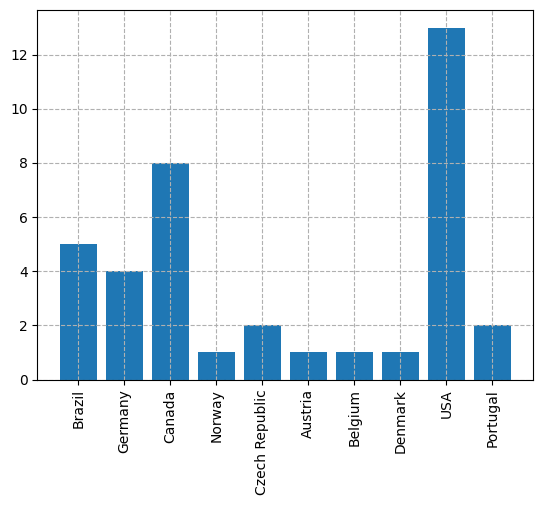

In [23]:
plt.bar(x = df.Pais, height= df.Frecuencia)
plt.xticks(rotation = 'vertical')
plt.grid(linestyle = '--')
plt.show()